# Pre-training phase

<br>

## - first part: click detection and split

In [1]:
import pandas as pd
import os
import librosa as librs
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
import pywt
import time
from pydub import AudioSegment
import wave

In [2]:
def show_statistics(detected_click_counts, waveletname):
    tasti = [str(i) for i in range(10)] + [chr(i) for i in range(ord('a'), ord('z') + 1)]
    true_click_counts = [25 for _ in range(36)]
    
    print(f"These are the statistics of the algorithm with the following parameters:")
    print(f"Wavelet transform used: {waveletname}")

    plt.bar(tasti, detected_click_counts)
    plt.xlabel('Keyboard keys')
    plt.ylabel('Number of clicks found')
    plt.title('Histogram of clicks at second intervals:')
    plt.show()

    total_clicks = sum(true_click_counts)
    total_clicks_found = sum(detected_click_counts)
    correct_clicks = 0
    missing_clicks = 0
    extra_clicks = 0
    for click in detected_click_counts:
        if(click < 25):
            missing_clicks += 25 - click
            correct_clicks += click
        elif (click > 25):
            extra_clicks += click -25
            correct_clicks += 25
        elif (click == 25):
            correct_clicks += click

    correct_percentage = ((100 * correct_clicks) / total_clicks)
    missing_percentage = ((100 * missing_clicks) / total_clicks)
    extra_percentage = ((100* extra_clicks) / total_clicks)


    print("Results in numbers: ")
    print(f"All click: {total_clicks}")
    print(f"Clicks found: {total_clicks_found}")
    print(f"Clicks found correctly: {correct_clicks}")
    print(f"Missing clicks: {missing_clicks}")
    print(f"Extra clicks found: {extra_clicks}")

    print("\nResults in percentages:")
    print(f"Percentage of clicks found correctly: {correct_percentage:.2f}%")
    print(f"Percentage of missing clicks: {missing_percentage:.2f}%")
    print(f"Percentage of extra clicks found: {extra_percentage:.2f}%")

In [3]:
def show_split(file_path, y, sr, peak_times):
    file_name = os.path.basename(file_path)
    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(len(y)) / sr, y, label='Onda Audio')
    for peak_time in peak_times:
        plt.axvline(x=peak_time, color='red', linestyle='--', alpha=0.7)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.title(f'Peaks Found on the Audio Wave: {file_name}')
    plt.legend()
    plt.show()

In [4]:
def split_audio(file_path, peak_times, click_time, output_dir):
    audio = AudioSegment.from_file(file_path)
    t=0;
    while t < (len(peak_times)) :
        start_time = int((peak_times[t]) * 1000)
        if(start_time < 0):
            start_time = 0;
        end_time = int((peak_times[t] + (click_time - 0.1)) * 1000)
        split_audio = audio[start_time:end_time]
        file_name_without_extension = os.path.splitext(os.path.basename(file_path))[0]
        output_filename = os.path.join(output_dir, f"{file_name_without_extension}_split_{t+1}.wav")
        split_audio.export(output_filename, format="wav")
        t+=1;

In [5]:
def peak_detection_and_split(file_path, waveletname, output_dir):
    click_time = 0.3;
    
    # Carica l'audio utilizzando Librosa
    y, sr = librs.load(file_path)

    # Calculation of wavelet transform, noise floor and threshold as twice the noise floor
    coefficients, frequencies = pywt.cwt(y, np.arange(1, 128), waveletname)
    noise_level = np.mean(np.abs(coefficients[:, :int(sr)]))
    threshold = 5 * noise_level
    
    # Trace analysis and memorization of moments when peaks are found.
    i = 0
    peak_times = []
    peak_count = 0
    while i < len(coefficients[0]):
        for j in range(len(coefficients)):
            maybe_peak = abs(coefficients[j, i] - coefficients[j, i - 1])
            # un picco è stato trovato
            if i > 0 and maybe_peak > threshold:
                time_of_peak = librs.samples_to_time(i, sr=sr)
                peak_times.append(time_of_peak)
                i += int(click_time * sr)  # Salta in avanti di x (secondi)
                peak_count += 1             
                break
        i += 1     

    # Call the function to split the audio
    split_audio(file_path, peak_times, click_time, output_dir)
    
    file_name = os.path.basename(file_path)
    
    print(f"The wave is {file_name} using wavelet {waveletname}")
    print(f"Value of threshold: {noise_level}")
    print(f"Number of peaks found: {len(peak_times)}\n")
    
    return peak_times, y, sr;

The wave is 0.wav using wavelet mexh
Value of threshold: 0.002487965626642108
Number of peaks found: 25



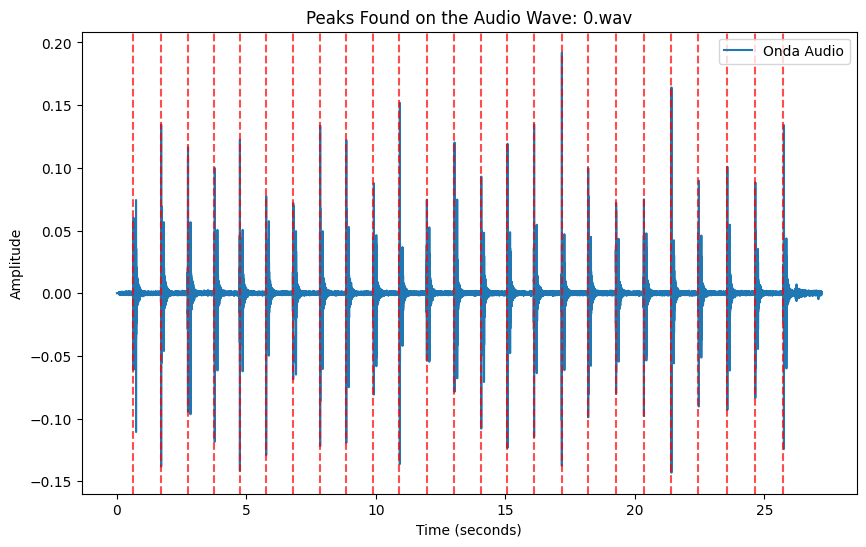

The wave is 1.wav using wavelet mexh
Value of threshold: 0.0029368579853326082
Number of peaks found: 25



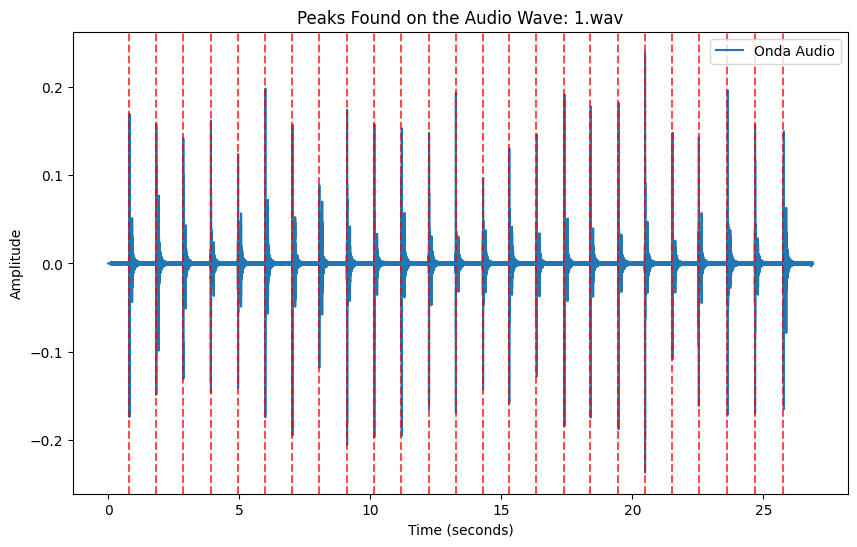

The wave is 2.wav using wavelet mexh
Value of threshold: 0.002426896942779422
Number of peaks found: 25



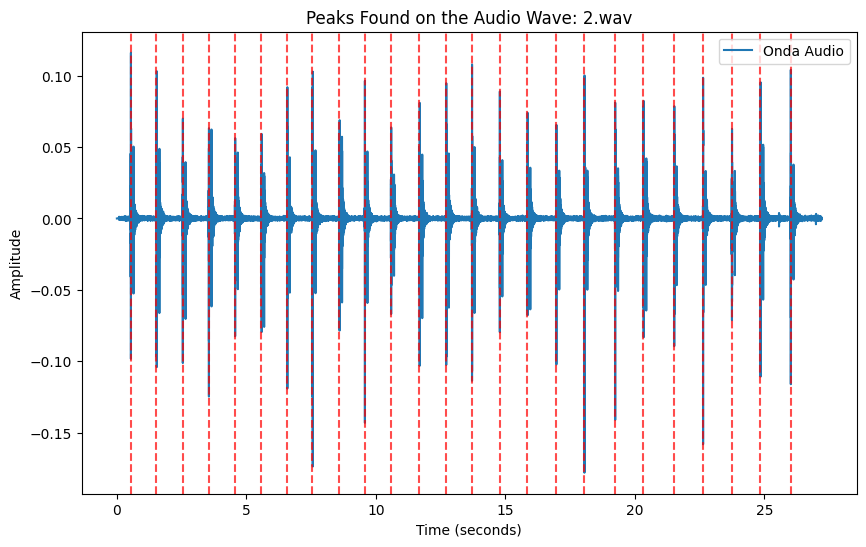

The wave is 3.wav using wavelet mexh
Value of threshold: 0.0037874537520110607
Number of peaks found: 25



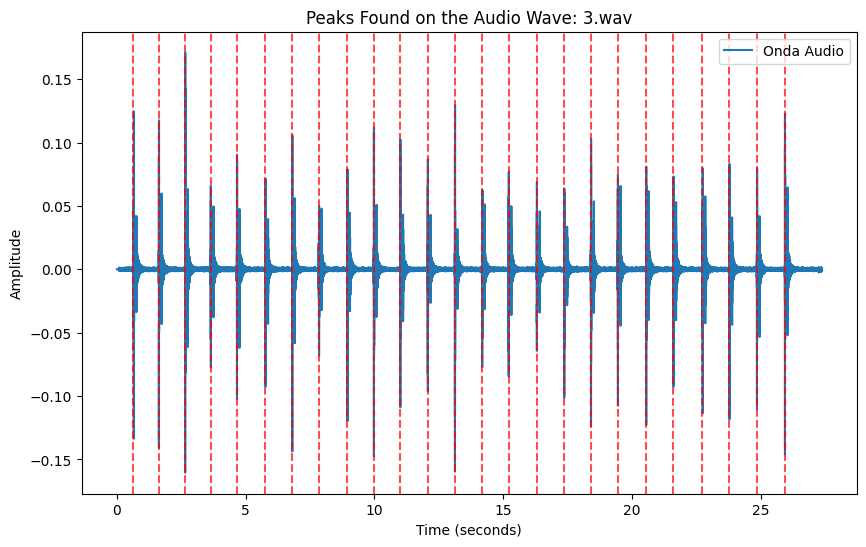

The wave is 4.wav using wavelet mexh
Value of threshold: 0.0031127778347581625
Number of peaks found: 25



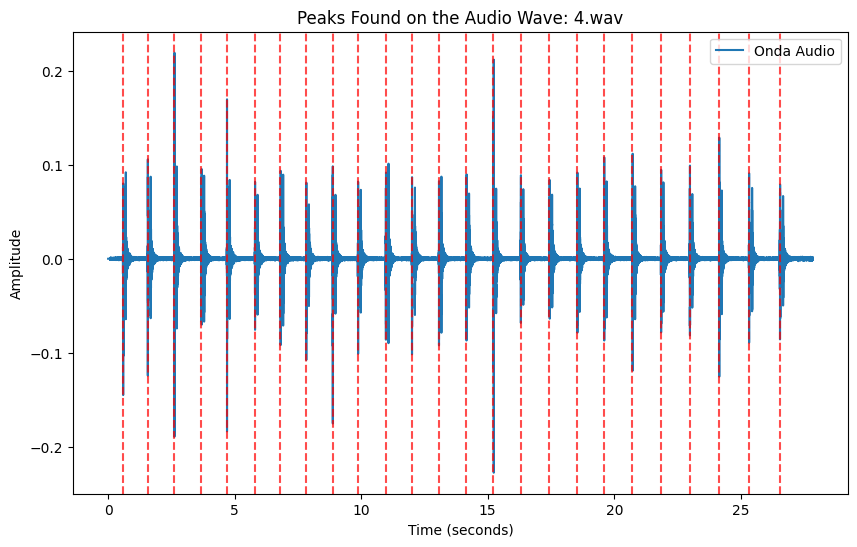

The wave is 5.wav using wavelet mexh
Value of threshold: 0.0024702586233615875
Number of peaks found: 25



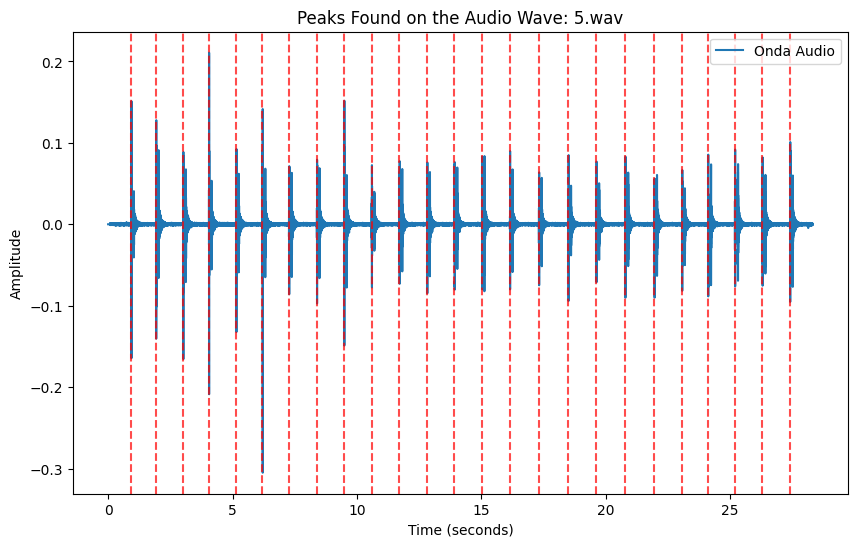

The wave is 6.wav using wavelet mexh
Value of threshold: 0.002889110706746578
Number of peaks found: 25



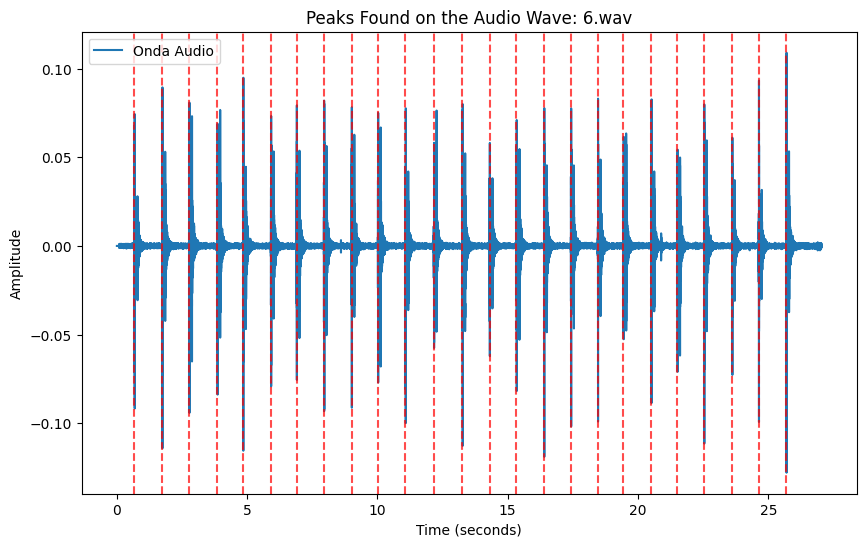

The wave is 7.wav using wavelet mexh
Value of threshold: 0.0028211423195898533
Number of peaks found: 25



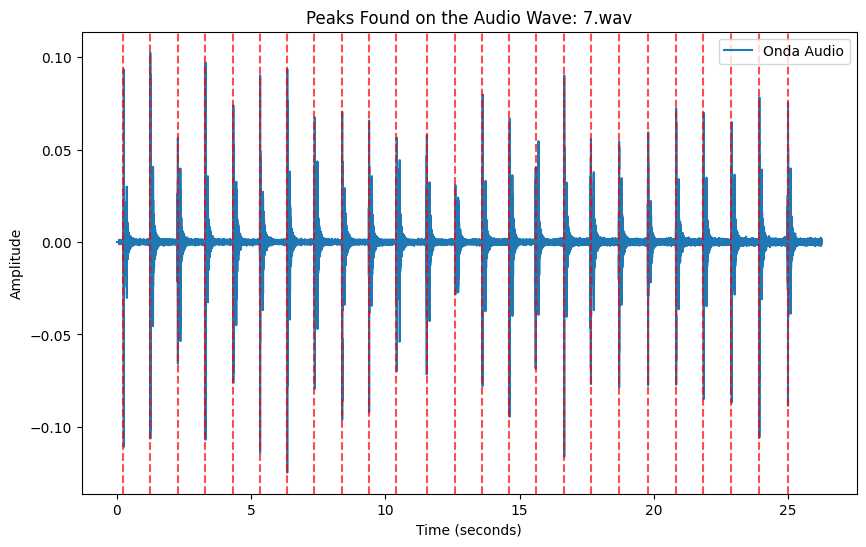

The wave is 8.wav using wavelet mexh
Value of threshold: 0.003236830933019519
Number of peaks found: 25



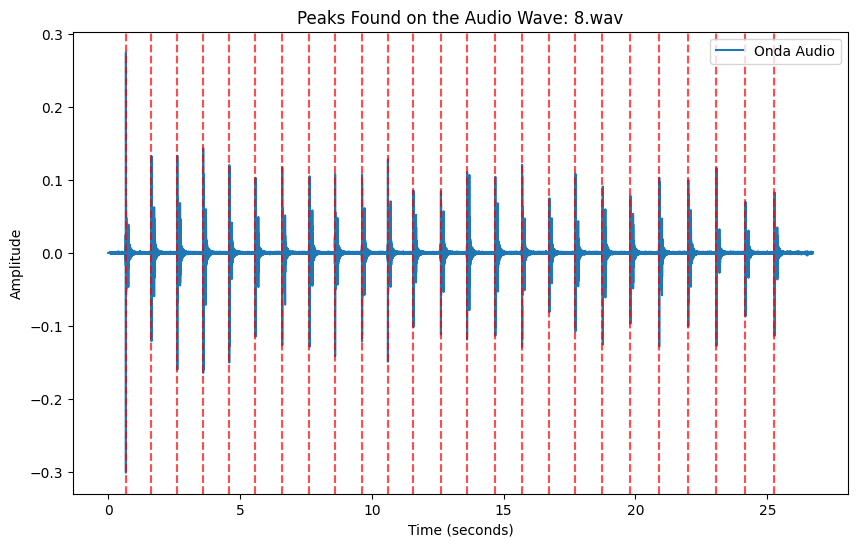

The wave is 9.wav using wavelet mexh
Value of threshold: 0.0026249070651829243
Number of peaks found: 25



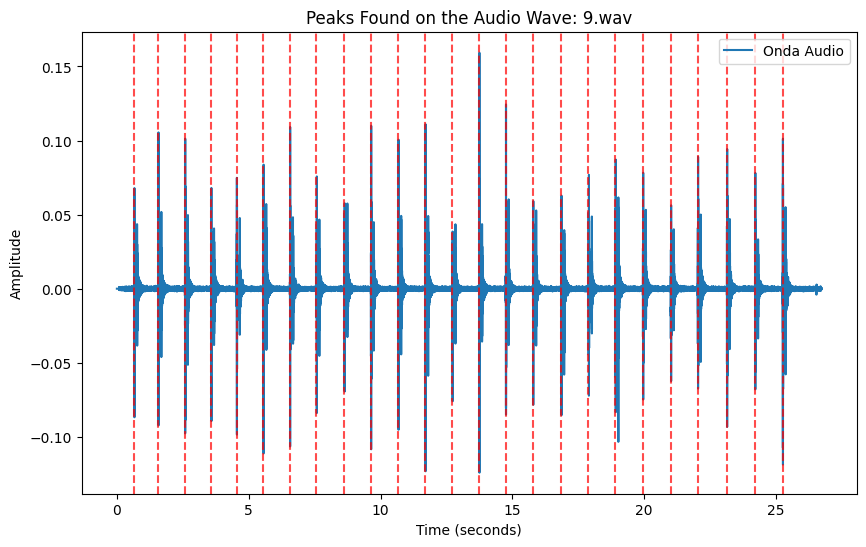

The wave is a.wav using wavelet mexh
Value of threshold: 0.003574405563995242
Number of peaks found: 25



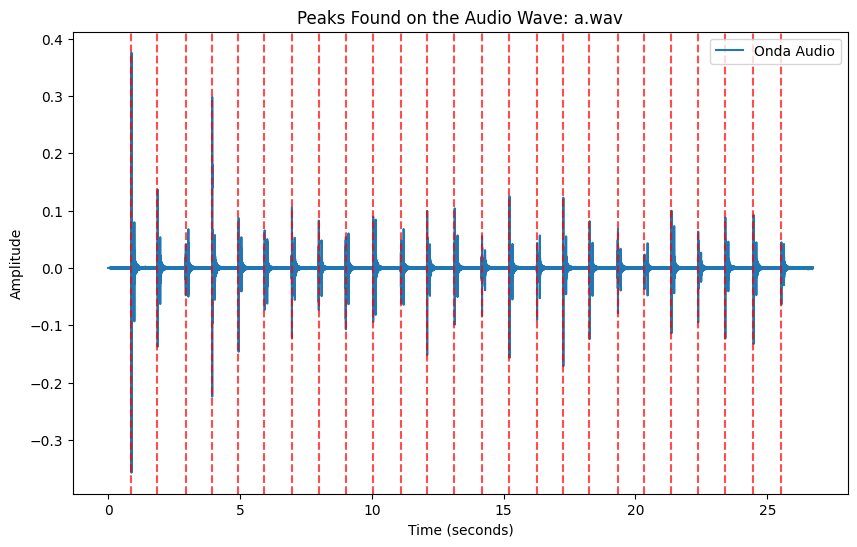

The wave is b.wav using wavelet mexh
Value of threshold: 0.00468437559902668
Number of peaks found: 25



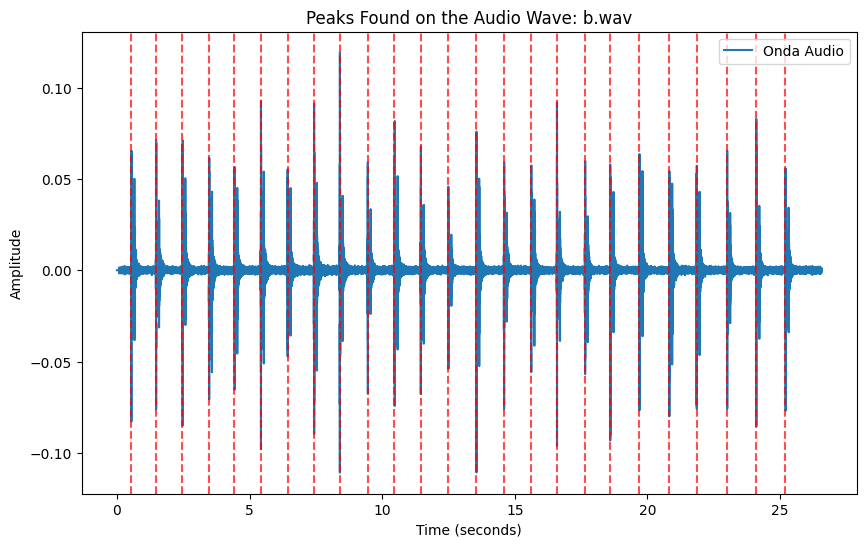

The wave is c.wav using wavelet mexh
Value of threshold: 0.0033961439039558172
Number of peaks found: 25



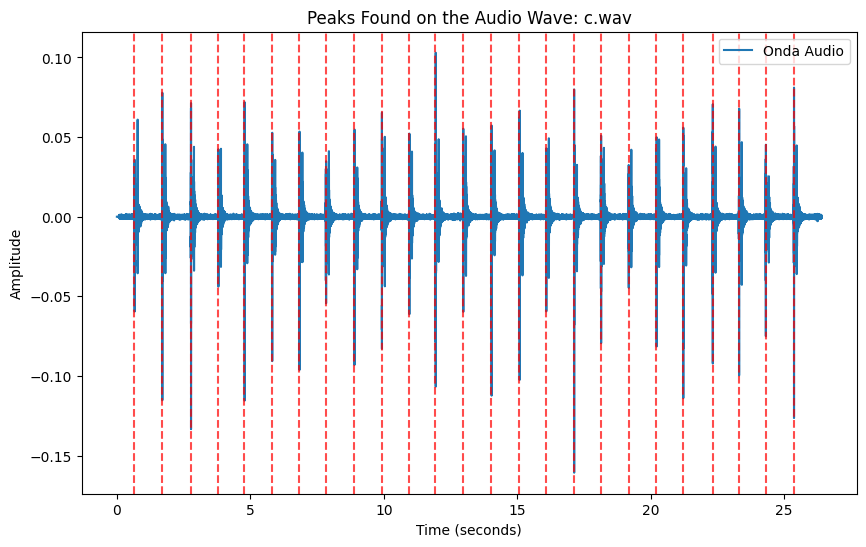

The wave is d.wav using wavelet mexh
Value of threshold: 0.0028054348658770323
Number of peaks found: 25



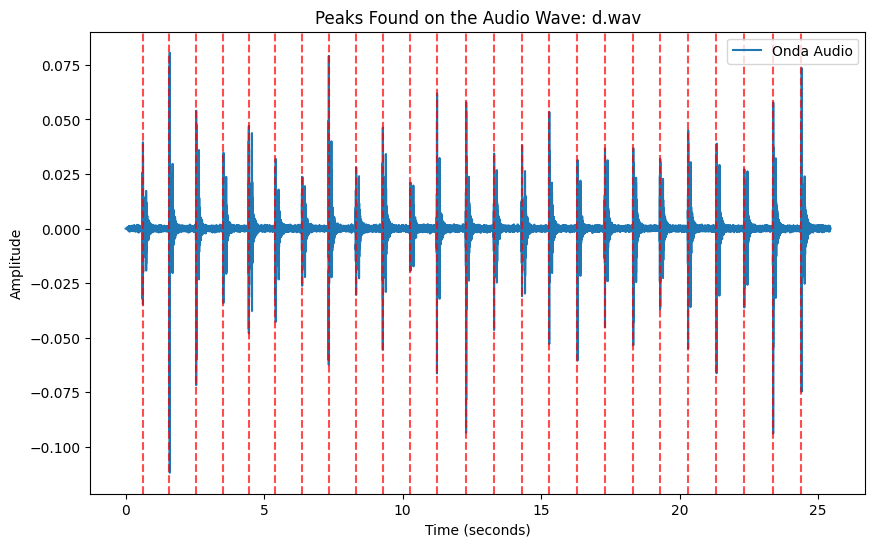

The wave is e.wav using wavelet mexh
Value of threshold: 0.0029738221783190966
Number of peaks found: 25



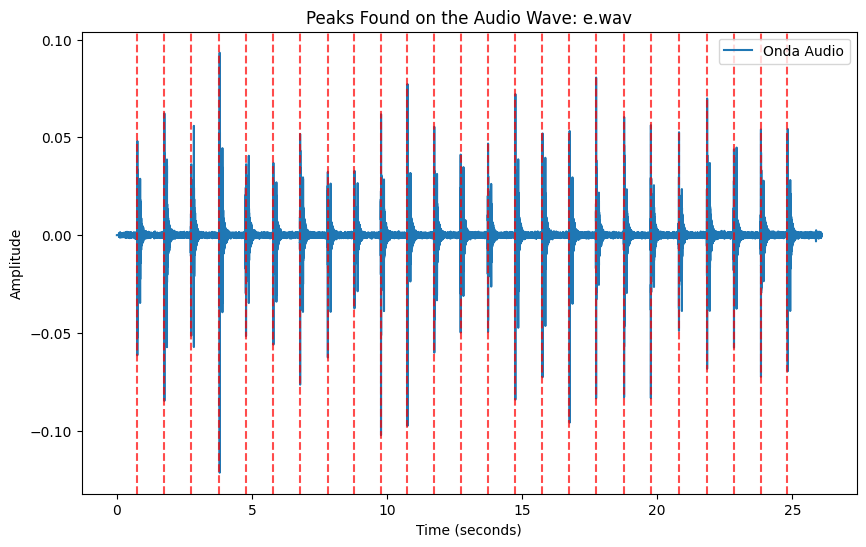

The wave is f.wav using wavelet mexh
Value of threshold: 0.0017038380028679967
Number of peaks found: 25



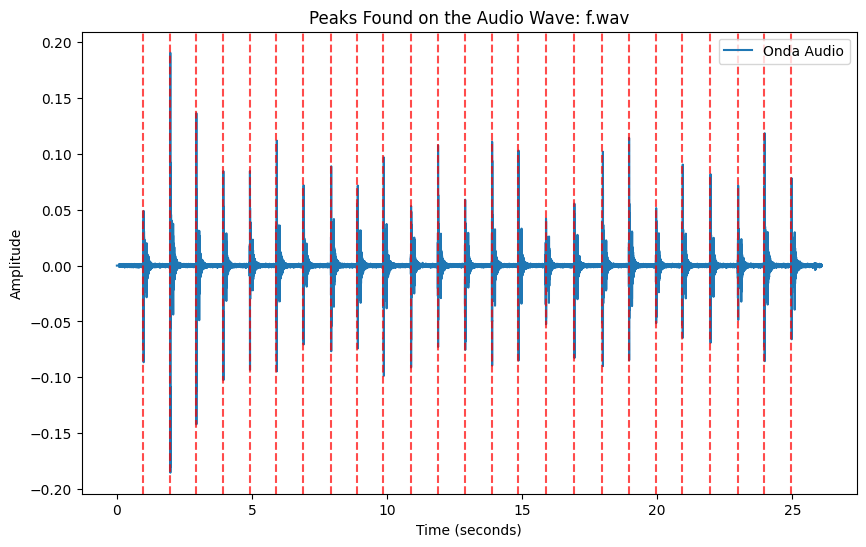

The wave is g.wav using wavelet mexh
Value of threshold: 0.003467029193416238
Number of peaks found: 25



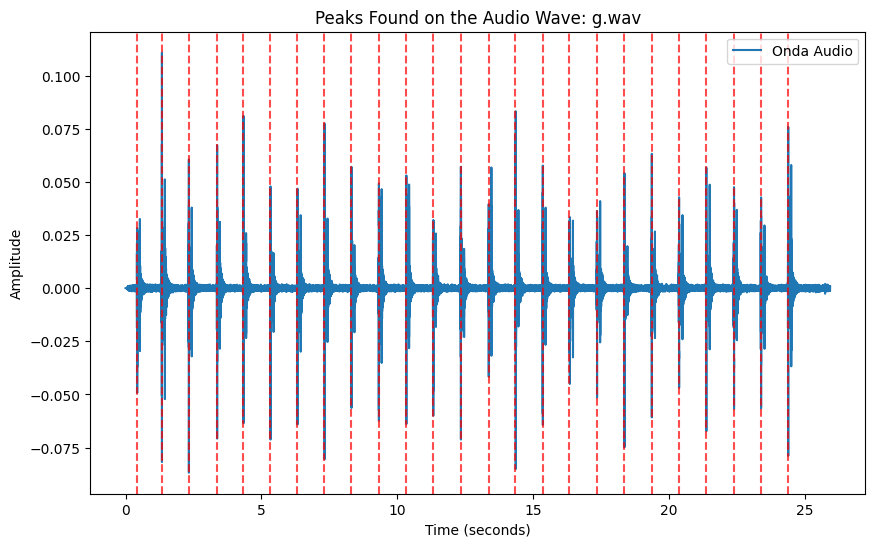

The wave is h.wav using wavelet mexh
Value of threshold: 0.0035238703712821007
Number of peaks found: 25



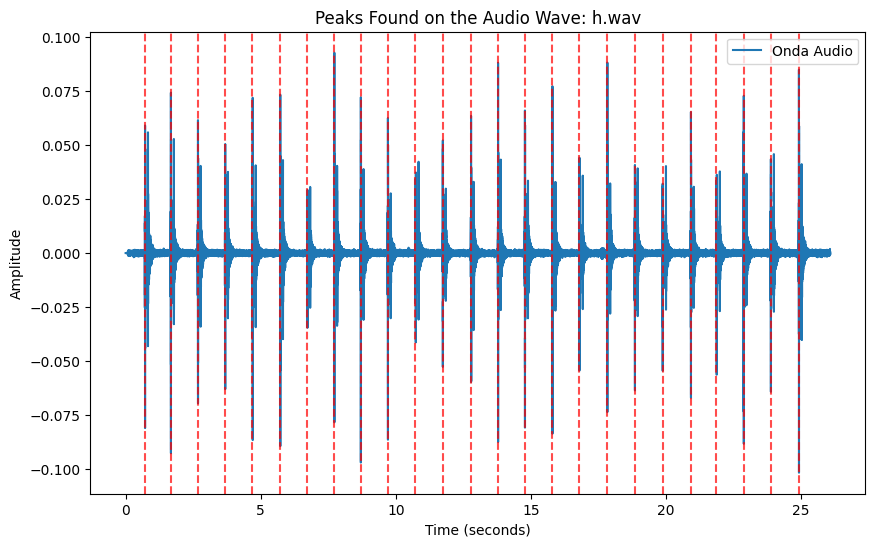

The wave is i.wav using wavelet mexh
Value of threshold: 0.0028482209891080856
Number of peaks found: 25



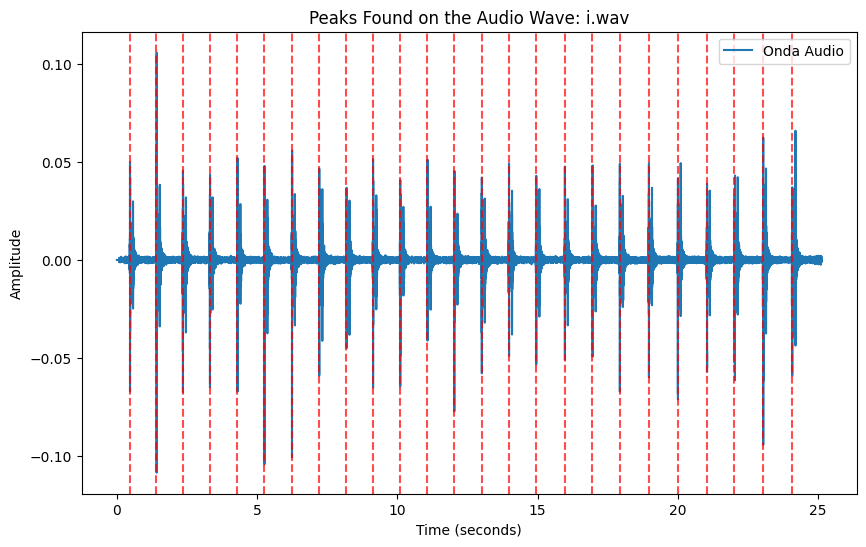

The wave is j.wav using wavelet mexh
Value of threshold: 0.004306788556277752
Number of peaks found: 25



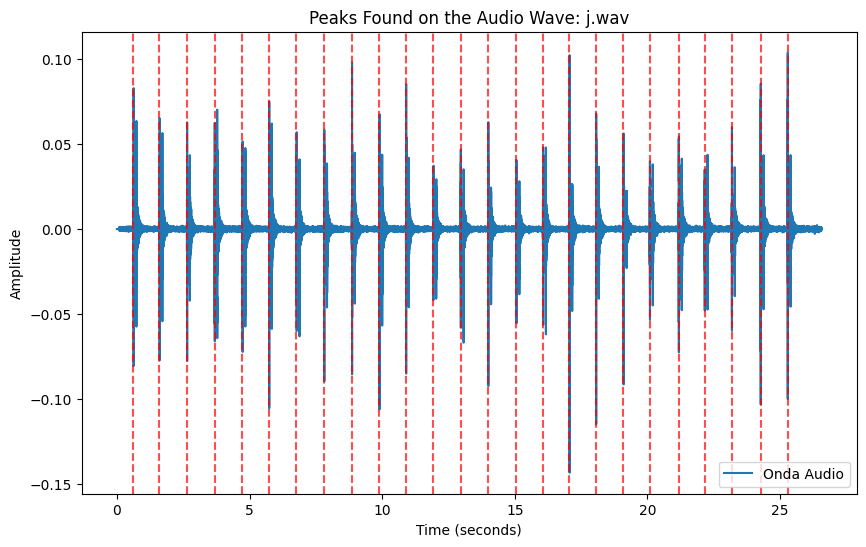

The wave is k.wav using wavelet mexh
Value of threshold: 0.004259225446730852
Number of peaks found: 25



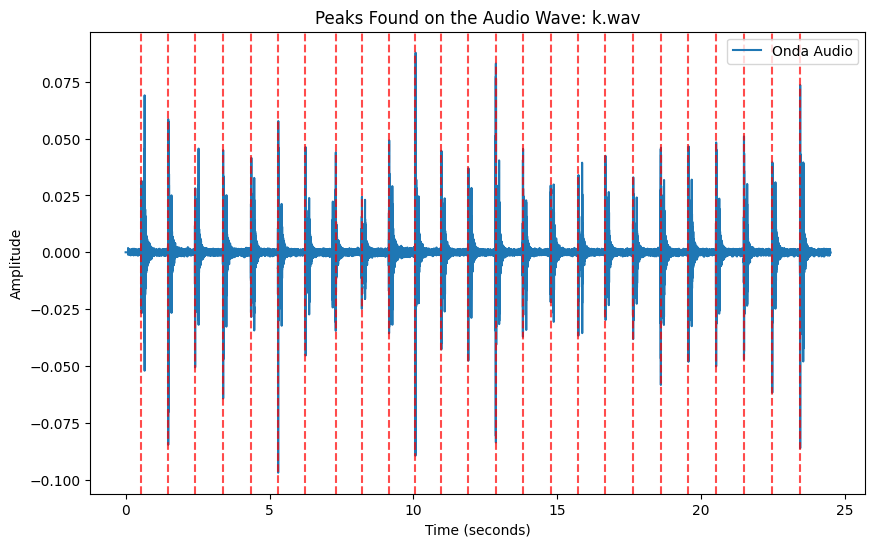

The wave is l.wav using wavelet mexh
Value of threshold: 0.0029545242432504892
Number of peaks found: 25



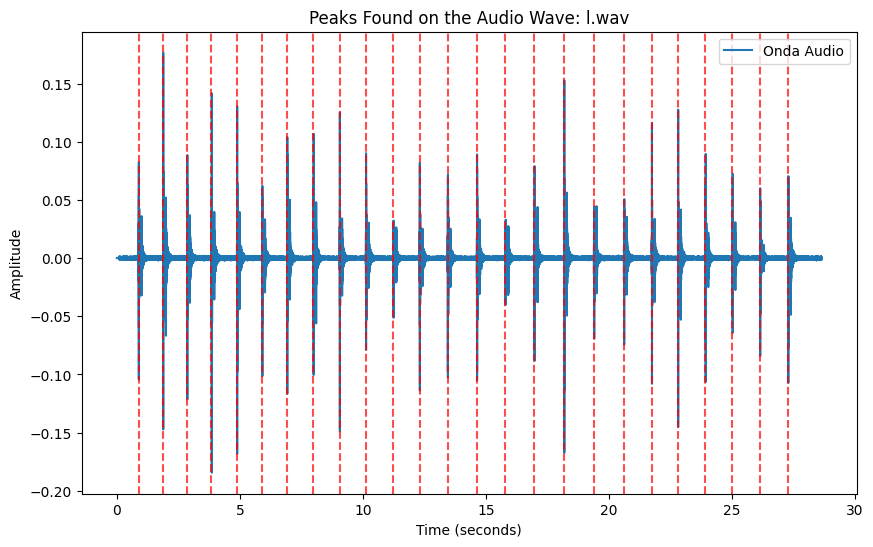

The wave is m.wav using wavelet mexh
Value of threshold: 0.005136524792760611
Number of peaks found: 25



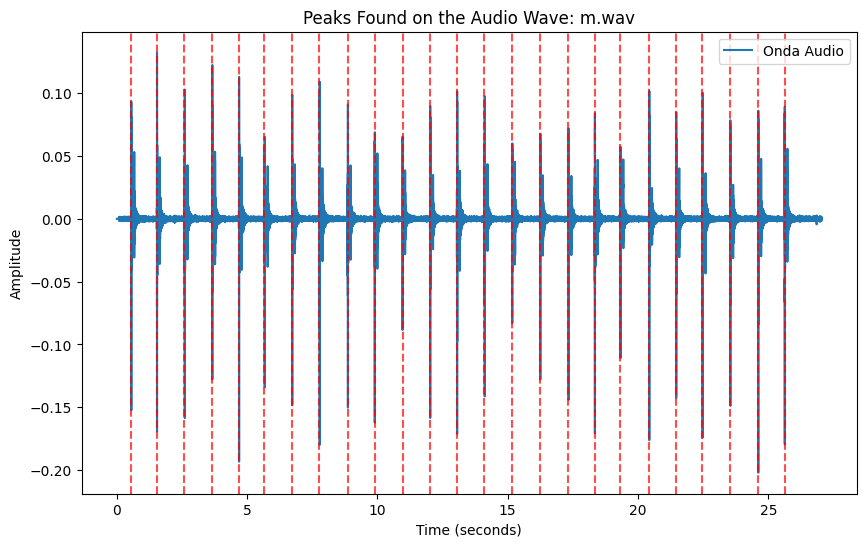

The wave is n.wav using wavelet mexh
Value of threshold: 0.00433358596637845
Number of peaks found: 25



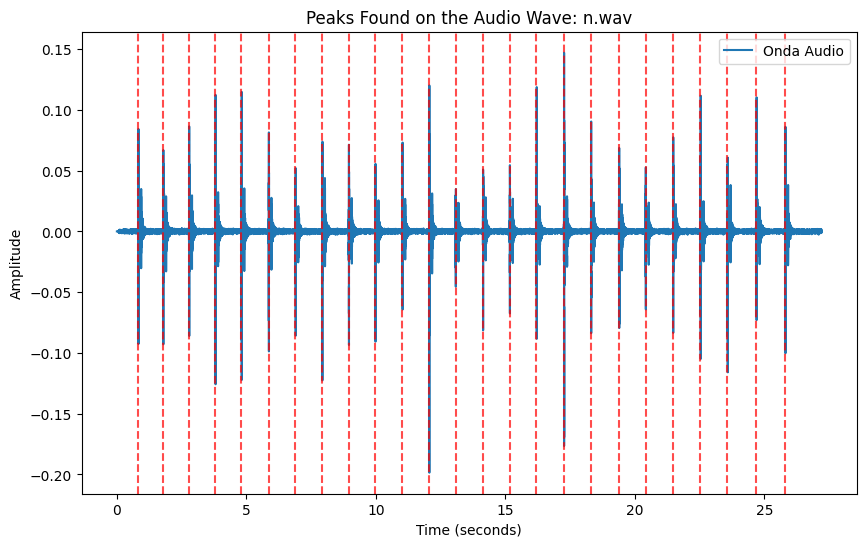

The wave is o.wav using wavelet mexh
Value of threshold: 0.0013077373150736094
Number of peaks found: 25



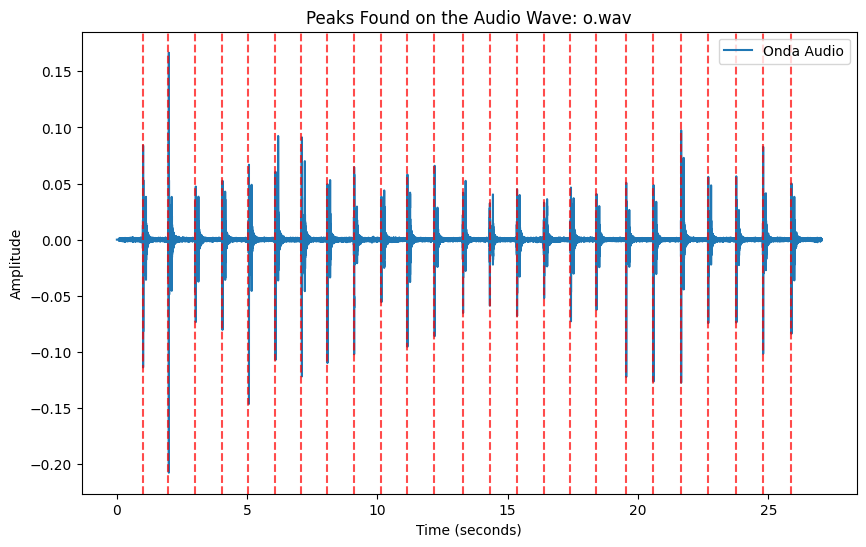

The wave is p.wav using wavelet mexh
Value of threshold: 0.0027373633347451687
Number of peaks found: 25



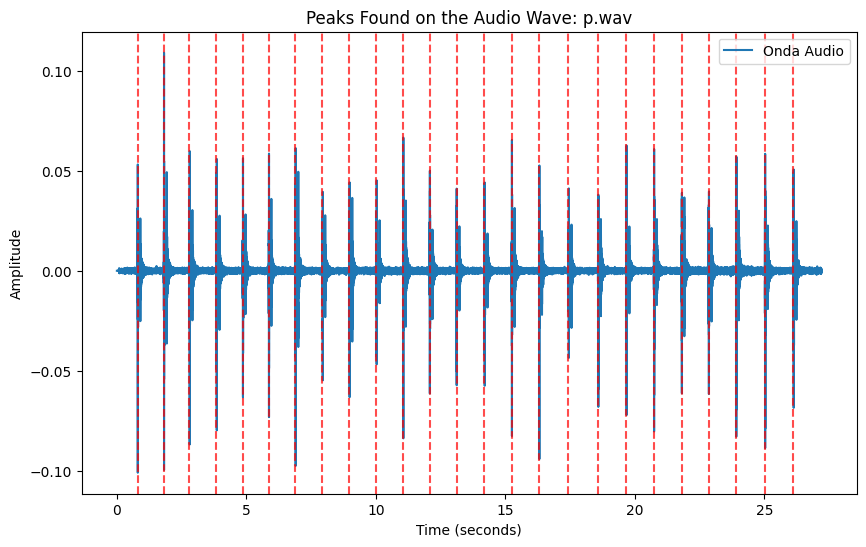

The wave is q.wav using wavelet mexh
Value of threshold: 0.0011952986242249608
Number of peaks found: 25



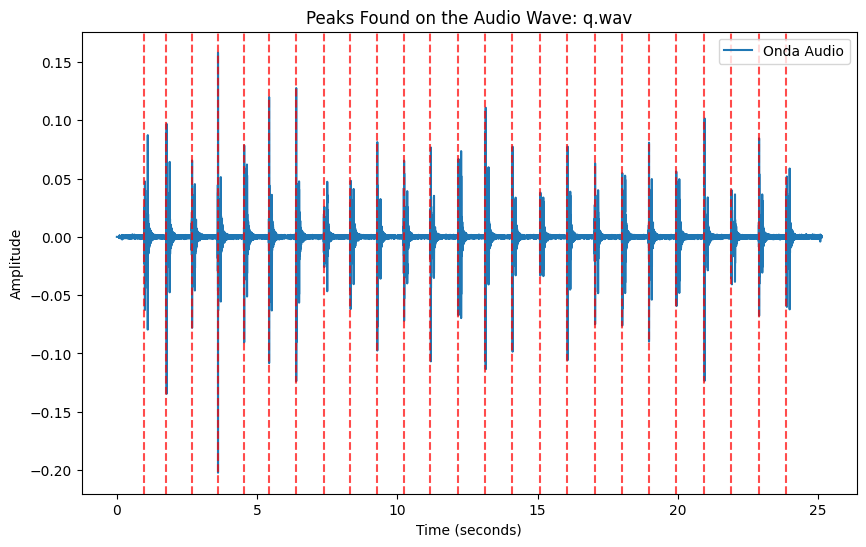

The wave is r.wav using wavelet mexh
Value of threshold: 0.0031308969482779503
Number of peaks found: 25



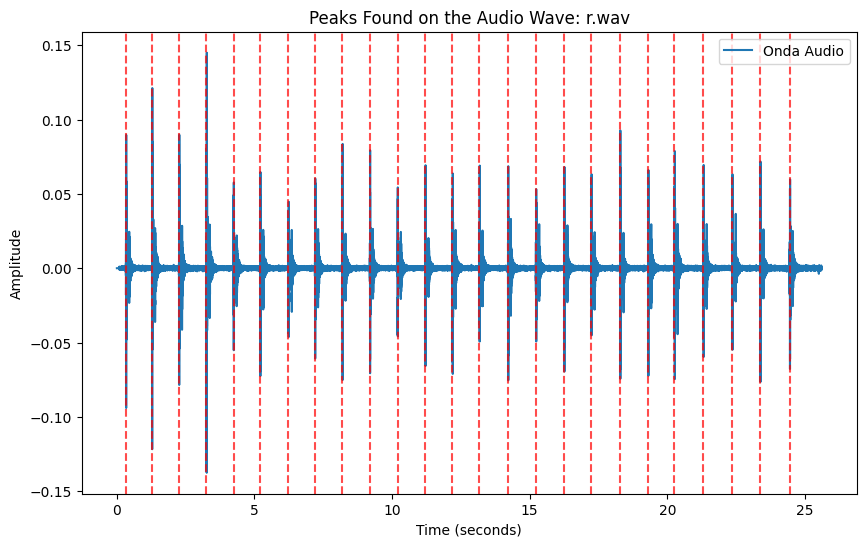

The wave is s.wav using wavelet mexh
Value of threshold: 0.0037979900371283293
Number of peaks found: 25



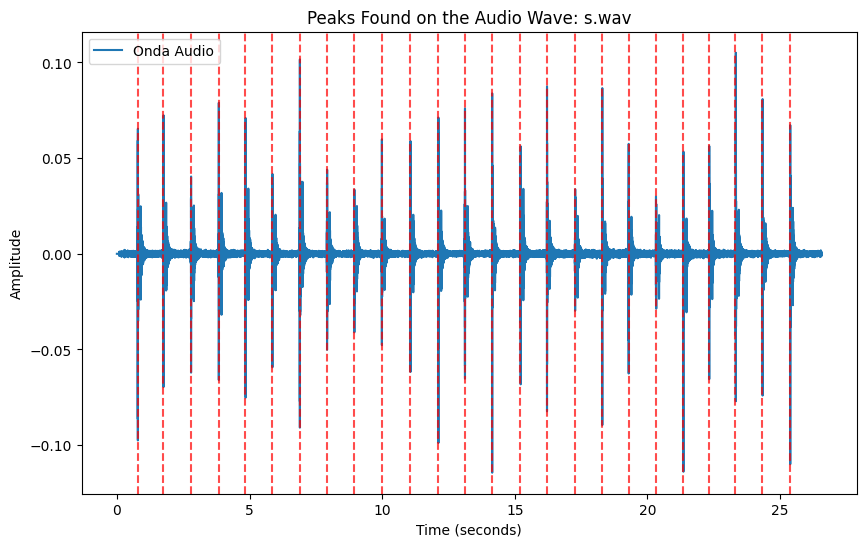

The wave is t.wav using wavelet mexh
Value of threshold: 0.0012015259126201272
Number of peaks found: 25



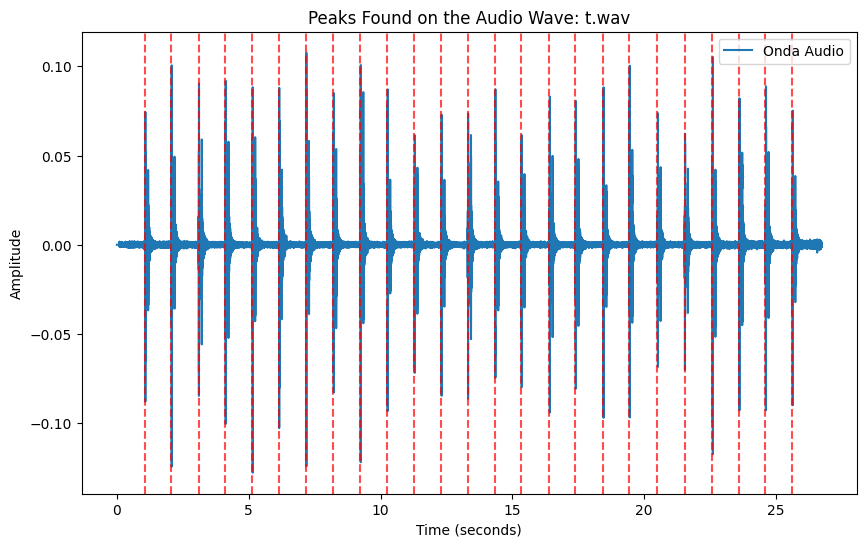

The wave is u.wav using wavelet mexh
Value of threshold: 0.0037639194633811712
Number of peaks found: 25



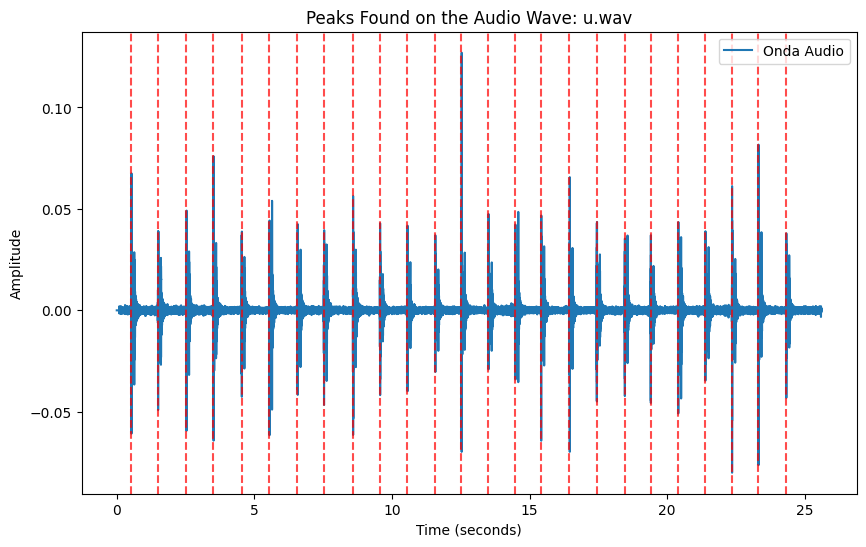

The wave is v.wav using wavelet mexh
Value of threshold: 0.004381419625133276
Number of peaks found: 25



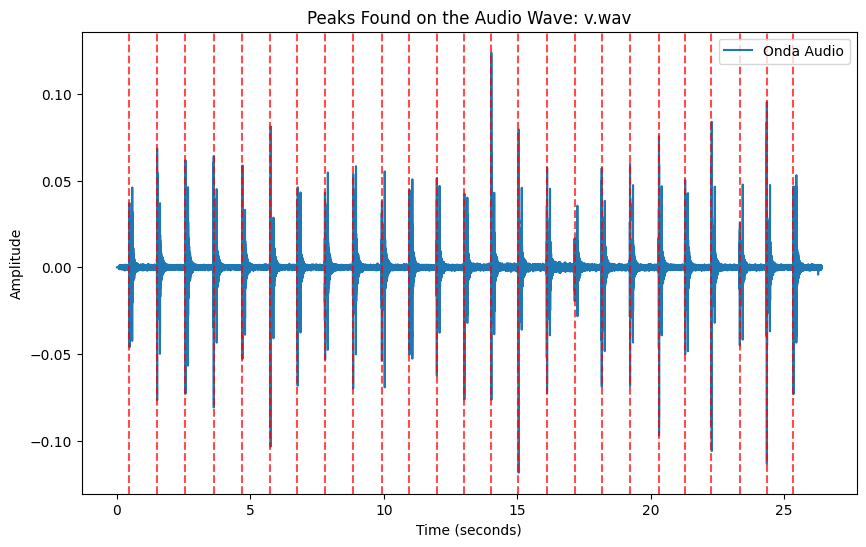

The wave is w​.wav using wavelet mexh
Value of threshold: 0.002807031152769923
Number of peaks found: 25



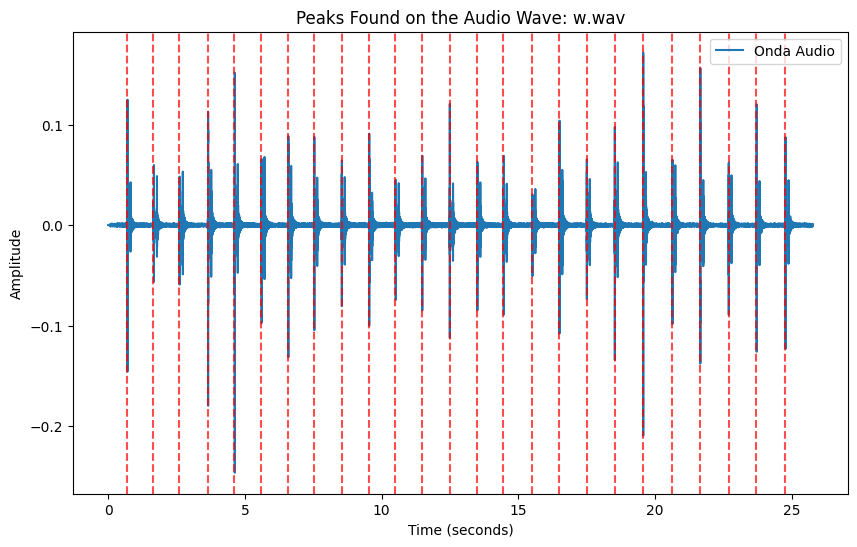

The wave is x.wav using wavelet mexh
Value of threshold: 0.0035800770856440067
Number of peaks found: 25



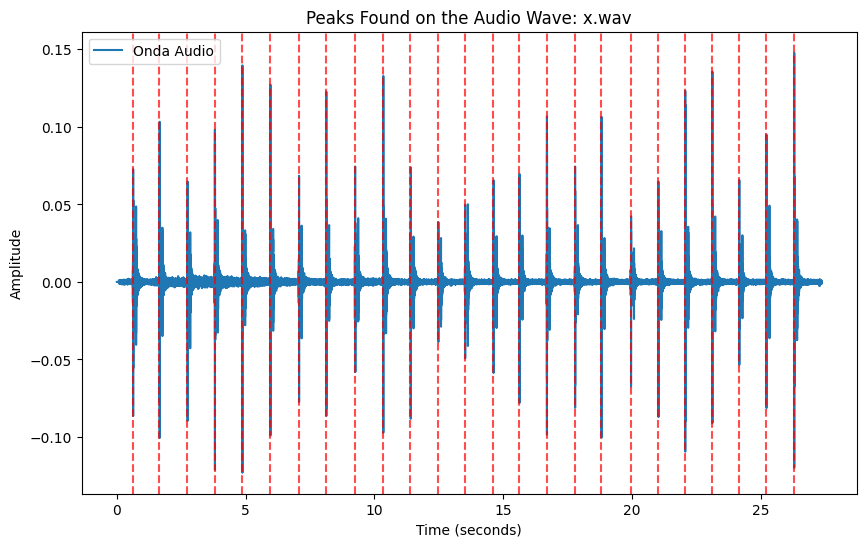

The wave is y.wav using wavelet mexh
Value of threshold: 0.0040361471474170685
Number of peaks found: 25



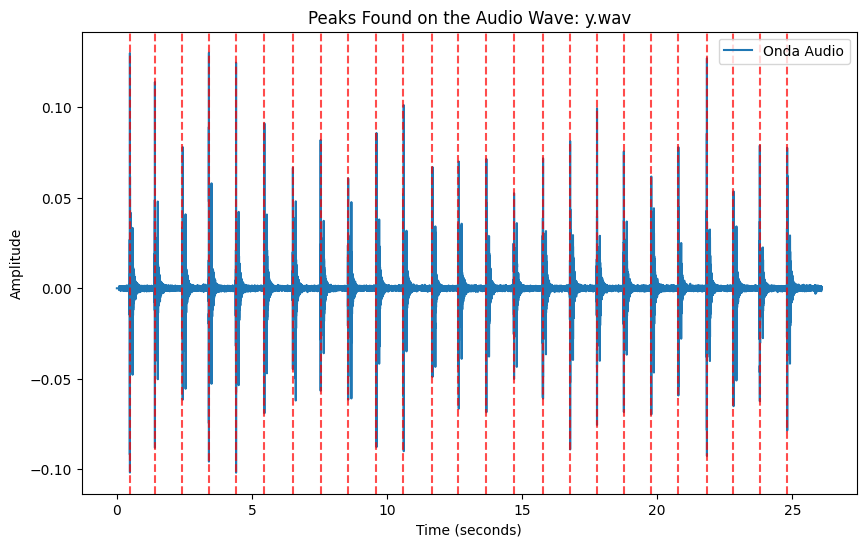

The wave is z.wav using wavelet mexh
Value of threshold: 0.004008530639111996
Number of peaks found: 25



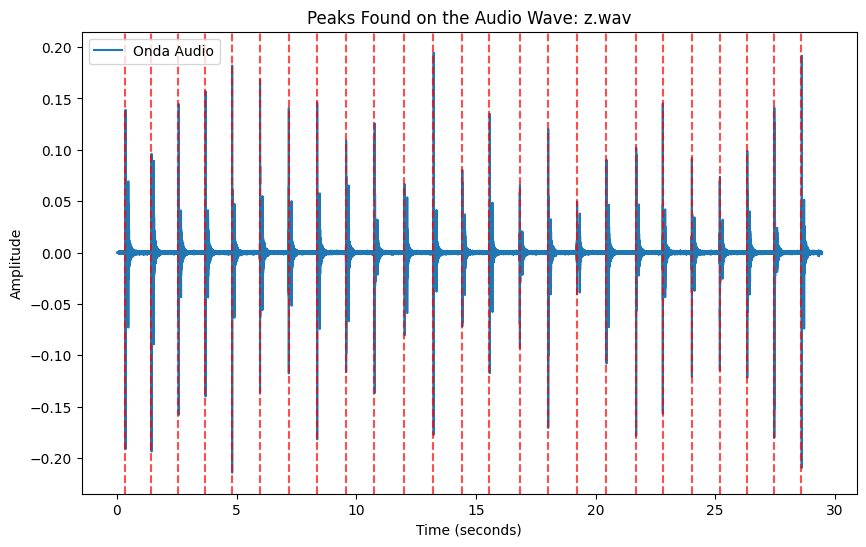

These are the statistics of the algorithm with the following parameters:
Wavelet transform used: mexh


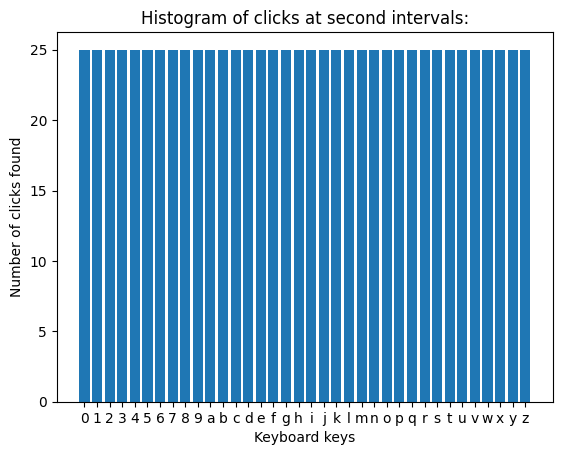

Results in numbers: 
All click: 900
Clicks found: 900
Clicks found correctly: 900
Missing clicks: 0
Extra clicks found: 0

Results in percentages:
Percentage of clicks found correctly: 100.00%
Percentage of missing clicks: 0.00%
Percentage of extra clicks found: 0.00%


In [7]:
# Detection, split and show statistic with mechanical keyboard and clicks with interval of 1 seconds with "mexh" wavelet

folder_path = 'AudioArchive/Dataset'
output_dir = 'AudioArchive/DatasetSplitted'
detected_click_counts = []
waveletname = "mexh"

# Ottieni la lista di file nella cartella
file_list = [f for f in os.listdir(folder_path) 
             if os.path.isfile(os.path.join(folder_path, f)) and f.endswith('.wav')]

# Itera su ogni file e applica la funzione recognize_peak
for file_name in file_list:
    file_path = os.path.join(folder_path, file_name)
    
    # Applica la funzione recognize_peak
    peak_times, y, sr = peak_detection_and_split(file_path, waveletname, output_dir)
    detected_click_counts.append(len(peak_times))
    show_split(file_path, y, sr, peak_times)
show_statistics(detected_click_counts, waveletname)

<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>

## - second part: data augmentation

In [8]:
import os
import librosa as librs
import numpy as np
import random
import soundfile as sf

In [10]:
# Set paths
input_dir = "AudioArchive/DatasetSplitted"
output_dir = "AudioArchive/DatasetSplittedAugmented"

# Data augmentation parameters
num_augmentations_per_file = 2  # Number of augmentations per input file
noise_factor_range = (0.00001, 0.0001)  # Amplitude of noise

def add_noise(audio, noise_factor):
    noise = np.random.normal(0, noise_factor, len(audio))
    augmented_audio = audio + noise
    return augmented_audio

def remove_non_ascii(text):
    return ''.join(char for char in text if ord(char) < 128)

def augmentation(input_dir, output_dir, num_augmentations_per_file, noise_factor_range):
    for file_name in os.listdir(input_dir):
        if file_name.endswith(".wav"):
            file_path = os.path.join(input_dir, file_name)
            audio, sr = librs.load(file_path)
            # Apply data augmentation techniques
            for _ in range(num_augmentations_per_file):
                augmented_audio1 = audio.copy()
                # Apply noise addition
                noise_factor = random.uniform(*noise_factor_range)
                augmented_audio = add_noise(augmented_audio1, noise_factor)
                # Create a clean version of file_name without non-ASCII characters
                clean_file_name = remove_non_ascii(file_name)
                # Save augmented audio
                output_file_name = f"augmented_{os.path.splitext(clean_file_name)[0]}_{_}.wav"
                output_file_path = os.path.join(output_dir, output_file_name)
                sf.write(output_file_path, augmented_audio, sr)
                # Save audio
                output_file_name1 = f"augmented_{os.path.splitext(clean_file_name)[0]}_{2}.wav"
                output_file_path1 = os.path.join(output_dir, output_file_name1)
                sf.write(output_file_path1, augmented_audio1, sr)
    print("Data augmentation complete.")
    
augmentation(input_dir, output_dir, num_augmentations_per_file, noise_factor_range)

Data augmentation complete.


<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>

## - third part: create csv file

In [11]:
import os
import csv

In [12]:
def list_files_in_directory(directory):
    file_list = []
    for filename in os.listdir(directory):
        if os.path.isfile(os.path.join(directory, filename)):
            file_list.append(filename)
    return file_list

def is_valid_char(char):
    if len(char) == 1 and char.isalpha() and char != '\u200b':  # Exclude zero-width space
        return True
    else:
        return False
    
def char_to_value(char):
    if char.isalpha():
        return ord(char.lower()) - ord('a') + 11
    else:
        try:
            return int(char)
        except ValueError:
            return char
    
def write_to_csv(file_list, output_filename):
    with open(output_filename, 'w', newline='', encoding='utf-8') as csvfile:  # Ensure utf-8 encoding
        csv_writer = csv.writer(csvfile)
        csv_writer.writerow(['slice_file_name', 'fold', 'classID', 'class'])
        for filename in sorted(file_list):  # Ordina i file nella lista
            filename_cleaned = ''.join(char for char in filename if ord(char) < 128)  # Remove non-ASCII characters
            input_string = filename_cleaned
            substrings = input_string.split('_')
            c = 0
            x = 0
            y = 0
            for substring in substrings:
                if c == 1:
                    if is_valid_char(substring):
                        y = substring
                        x = int(char_to_value(substring))
                    else:
                        y = int(substring)
                        x = int(substring) + 1
                c += 1
            csv_writer.writerow([filename_cleaned, '16', str(x), str(y)])

In [13]:
input_directory = "AudioArchive/DatasetSplittedAugmented"
output_filename = "augmented_audio_list.csv"
files_list = list_files_in_directory(input_directory)
write_to_csv(files_list, output_filename)
print(f"File list has been written to {output_filename}")

File list has been written to augmented_audio_list.csv


<br>
<br>
<br>
<br>
<br>
<br>

# TEST

The wave is password_budapesthotel.wav using wavelet mexh
Value of threshold: 0.0010522287338972092
Number of peaks found: 13



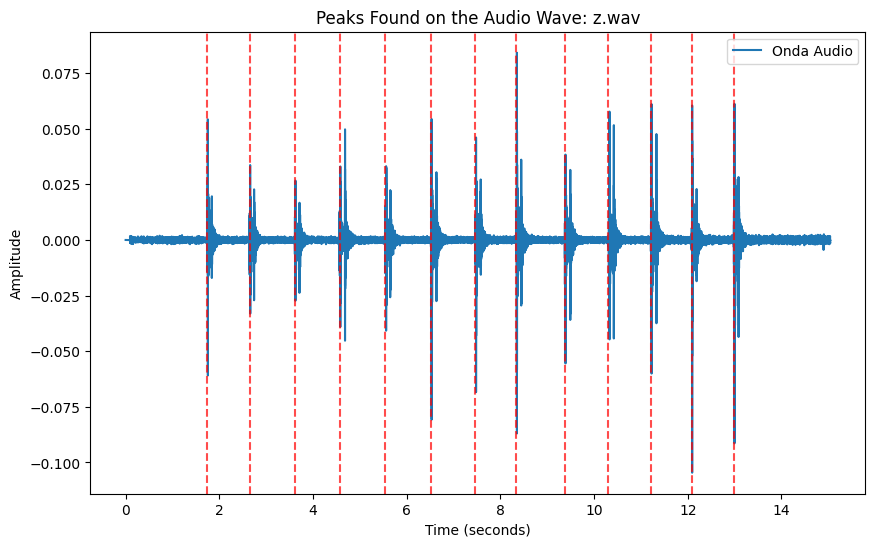

In [14]:
input_path = 'AudioArchive/TestAudio/password_budapesthotel.wav'
output_dir = 'AudioArchive/TestSplitted'
detected_click_counts = []
waveletname = "mexh" 

# Applica la funzione recognize_peak
peak_times, y, s = peak_detection_and_split(input_path, waveletname, output_dir)
detected_click_counts.append(len(peak_times))
show_split(file_path, y, s, peak_times)

The wave is password_tesirusso2024_veloce.wav using wavelet mexh
Value of threshold: 0.0010990563314408064
Number of peaks found: 13



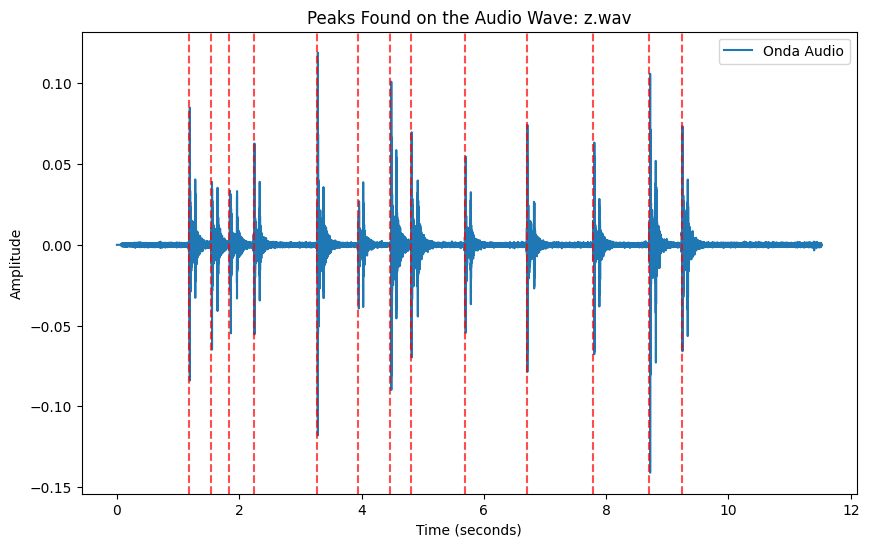

In [15]:
input_path = 'AudioArchive/TestAudio/password_tesirusso2024_veloce.wav'
output_dir = 'AudioArchive/TestSplitted'
detected_click_counts = []
waveletname = "mexh" 

# Applica la funzione recognize_peak
peak_times, y, s = peak_detection_and_split(input_path, waveletname, output_dir)
detected_click_counts.append(len(peak_times))
show_split(file_path, y, s, peak_times)